In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import drive
import statsmodels.api as sm
import numpy as np

In [ ]:
file_path = "/content/drive/MyDrive/Analisis matemático/FINALMODELOajustelocal.csv"
df_modelo = pd.read_csv(file_path, encoding='latin1')

In [ ]:
df_modelo["LOG_POBLACION_TOTAL"] = np.log(df_modelo["POBLACION_TOTAL"].replace(0, np.nan))
df_modelo["LOG_POBLACION_20_24"] = np.log(df_modelo["POBLACION_20_24"].replace(0, np.nan))


In [ ]:
# 1. Crear nuevos dummies

# China moderna (año >= 2000)
df_modelo["DUMMY_CHINA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "China" and row["YEAR"] >= 2008 else 0, axis=1)
df_modelo["DUMMY_KOREA_MODERNA"] = df_modelo.apply(lambda row: 1 if row["COUNTRY"] == "South Korea" and row["YEAR"] >= 1988 else 0, axis=1)

# Francia (en general)
df_modelo["DUMMY_FRANCE"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "France" else 0)
df_modelo["DUMMY_ITALY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Italy" else 0)
df_modelo["DUMMY_HUNGARY"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Hungary" else 0)
df_modelo["DUMMY_JAPAN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Japan" else 0)
df_modelo["DUMMY_BULGARIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Bulgaria" else 0)
df_modelo["DUMMY_CUBA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Cuba" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_NETHERLANDS"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Netherlands" else 0)
df_modelo["DUMMY_ROMANIA"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Romania" else 0)
df_modelo["DUMMY_SPAIN"] = df_modelo["COUNTRY"].apply(lambda x: 1 if x == "Spain" else 0)
# 2. Redefinir X con las nuevas variables
X = df_modelo[[
    "PIB_REAL",
    "POBLACION_TOTAL_CENTRADO",
    "POBLACION_20_24_CENTRADO",
    "TASA_MORTALIDAD_INFANTIL_CENTRADO",
    "LOCAL",
    "VECINO",
   #"DUMMY_CHINA_MODERNA",
    "DUMMY_RUSSIA",
    "DUMMY_USA",
    "DUMMY_GERMANY",
   # "BOICOT_1980",
   # "BOICOT_1984",
    "DUMMY_AUSTRALIA",
    "DUMMY_UK",
    "DUMMY_FRANCE",
    "DUMMY_ITALY",
    "DUMMY_HUNGARY",
    "DUMMY_JAPAN",
    "DUMMY_BULGARIA",
    "DUMMY_CUBA",
    "DUMMY_KOREA_MODERNA",
    "DUMMY_NETHERLANDS",
    "DUMMY_ROMANIA",
    "DUMMY_SPAIN"

]]

# 3. Agregar constante
X = sm.add_constant(X)

# 4. Definir y
y= df_modelo["LOG_PROP_MEDALLAS"]

# 5. Ajustar el modelo
modelo= sm.OLS(y, X).fit()

# 6. Mostrar el resumen del modelo
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:      LOG_PROP_MEDALLAS   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     59.25
Date:                Wed, 30 Apr 2025   Prob (F-statistic):          5.68e-161
Time:                        15:59:31   Log-Likelihood:                -1568.2
No. Observations:                1059   AIC:                             3180.
Df Residuals:                    1037   BIC:                             3290.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [ ]:
import numpy as np

# 1. Predecir log(ŵ_it) con el modelo
log_predicciones = modelo.predict(X)

# 2. Destransformar: volver a escala real (ŵ_it)
predicciones = np.exp(log_predicciones)

# 3. Agregar las predicciones al dataframe de modelado
df_modelo["PROP_MEDALLAS_PREDICHA"] = predicciones

# 4. Opcional: calcular error absoluto entre proporción real y predicha
df_modelo["ERROR_ABSOLUTO"] = np.abs(df_modelo["PROP_MEDALLAS"] - df_modelo["PROP_MEDALLAS_PREDICHA"])

# 5. Mostrar ejemplo de tabla de resultados
resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_TOTALES_POR_PAIS_POR_AÑO",
    "PROP_MEDALLAS",
    "PROP_MEDALLAS_PREDICHA",
    "ERROR_ABSOLUTO"
]].sort_values(by="ERROR_ABSOLUTO", ascending=False)

# Mostrar los 10 países con mayor error
resultados.head(10)


,COUNTRY,YEAR,MEDALLAS_TOTALES_POR_PAIS_POR_AÑO,PROP_MEDALLAS,PROP_MEDALLAS_PREDICHA,ERROR_ABSOLUTO
797,Russia,1980,442,0.319134,0.154676,0.164457
353,Germany,1972,253,0.208230,0.094991,0.113239
354,Germany,1976,273,0.206818,0.096202,0.110616
1019,United States,1984,352,0.238644,0.147558,0.091086
357,Germany,1988,296,0.187223,0.096281,0.090942
796,Russia,1976,286,0.216667,0.128409,0.088258
355,Germany,1980,264,0.190614,0.126510,0.064104
798,Russia,1988,300,0.189753,0.125826,0.063928
351,Germany,1964,116,0.112731,0.053242,0.059489
792,Russia,1960,169,0.185919,0.128372,0.057547


In [ ]:
# 1. Primero, recuperar el total de medallas entregadas cada año
total_medallas_por_ano = df_modelo.groupby("YEAR")["MEDALLAS_TOTALES_POR_PAIS_POR_AÑO"].transform("sum")

# 2. Calcular las medallas reales y predichas en números absolutos
df_modelo["MEDALLAS_REALES"] = df_modelo["PROP_MEDALLAS"] * total_medallas_por_ano
df_modelo["MEDALLAS_PREDICHAS"] = df_modelo["PROP_MEDALLAS_PREDICHA"] * total_medallas_por_ano

# 3. Calcular error absoluto en número de medallas
df_modelo["ERROR_ABSOLUTO_MEDALLAS"] = np.abs(df_modelo["MEDALLAS_REALES"] - df_modelo["MEDALLAS_PREDICHAS"])

# 4. Armar la tabla ordenada
tabla_resultados = df_modelo[[
    "COUNTRY",
    "YEAR",
    "MEDALLAS_REALES",
    "MEDALLAS_PREDICHAS",
    "ERROR_ABSOLUTO_MEDALLAS"
]].sort_values(by="ERROR_ABSOLUTO_MEDALLAS", ascending=False)

# 5. Mostrar los 10 países con mayor error absoluto
tabla_resultados.head(15)


,COUNTRY,YEAR,MEDALLAS_REALES,MEDALLAS_PREDICHAS,ERROR_ABSOLUTO_MEDALLAS
797,Russia,1980,442.000000,214.226674,227.773326
354,Germany,1976,273.000000,126.986982,146.013018
357,Germany,1988,295.999999,152.220842,143.779157
353,Germany,1972,253.000000,115.414507,137.585494
1019,United States,1984,352.000000,217.648614,134.351386
366,Germany,2024,108.000000,234.294000,126.294001
188,China,2020,148.999999,269.813485,120.813486
796,Russia,1976,286.000000,169.499487,116.500514
803,Russia,2008,141.999999,252.534131,110.534132
805,Russia,2016,114.999999,222.620023,107.620024


In [ ]:
df=tabla_resultados

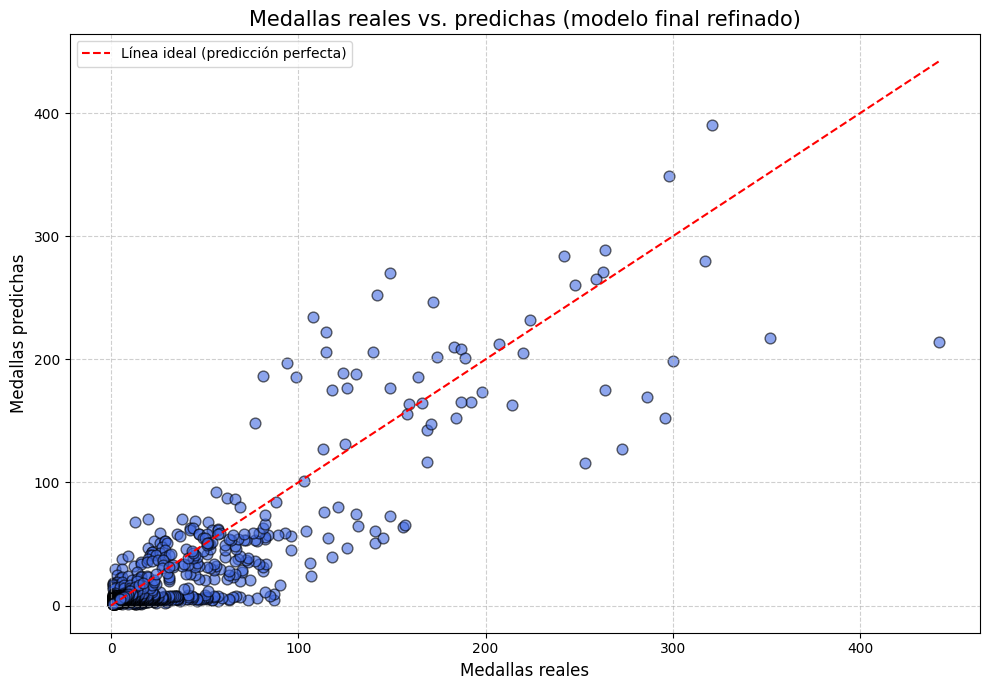

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar archivo de resultados
#df = pd.read_excel("RESULTADOS5.xlsx")  # Asegúrate de tener este archivo en tu carpeta de trabajo

# 2. Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# 3. Seleccionar las columnas necesarias y eliminar valores nulos
df_grafico = df[["COUNTRY", "YEAR", "MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].dropna()

# 4. Crear gráfico
plt.figure(figsize=(10, 7))
plt.scatter(
    df_grafico["MEDALLAS_REALES"],
    df_grafico["MEDALLAS_PREDICHAS"],
    alpha=0.6,
    color='royalblue',
    edgecolors='black',
    s=60,
    marker='o'
)
plt.plot(
    [0, df_grafico["MEDALLAS_REALES"].max()],
    [0, df_grafico["MEDALLAS_REALES"].max()],
    'r--',
    label='Línea ideal (predicción perfecta)'
)

# 5. Etiquetas y formato
plt.title("Medallas reales vs. predichas (modelo final refinado)", fontsize=15)
plt.xlabel("Medallas reales", fontsize=12)
plt.ylabel("Medallas predichas", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Mostrar
plt.show()


In [ ]:
import pandas as pd

# 1. Cargar archivo de resultados
df.columns = df.columns.str.strip()

# 2. Agrupar por país y sumar medallas reales y predichas
tabla_resumen = df.groupby("COUNTRY")[["MEDALLAS_REALES", "MEDALLAS_PREDICHAS"]].sum().reset_index()

# 3. Calcular el error absoluto total por país
tabla_resumen["ERROR_ABSOLUTO_TOTAL"] = abs(tabla_resumen["MEDALLAS_REALES"] - tabla_resumen["MEDALLAS_PREDICHAS"])

# 4. Renombrar columnas para claridad
tabla_resumen.columns = ["COUNTRY", "MEDALLAS_REALES_TOTALES", "MEDALLAS_PREDICHAS_TOTALES", "ERROR_ABSOLUTO_TOTAL"]

# 5. Ordenar por error total (opcional: puedes cambiar a orden por medallas reales si lo prefieres)
tabla_resumen = tabla_resumen.sort_values("ERROR_ABSOLUTO_TOTAL", ascending=False)

# 6. Mostrar las primeras filas
print(tabla_resumen.head(15))

# (Opcional) Guardar a Excel
tabla_resumen.to_excel("resumen_medallas_totales_con_errores.xlsx", index=False)


            COUNTRY  MEDALLAS_REALES_TOTALES  MEDALLAS_PREDICHAS_TOTALES  \
21           Canada               611.000003                  119.728970   
16           Brazil               576.000001                   92.678068   
103          Serbia               517.999997                   65.871071   
94           Poland               518.999997                   83.661683   
82      Netherlands               789.000000                  547.323525   
83      New Zealand               330.000001                   92.638343   
112          Sweden               350.000001                  117.444439   
31   Czech Republic               310.999999                   84.919487   
6         Australia              1410.000002                 1186.327841   
32          Denmark               329.999996                  114.469043   
24            China              1234.000000                 1024.900354   
3         Argentina               266.000002                   63.050433   
125         